In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.9 MB/s eta 0:00:00a 0:00:01


In [ ]:
import gc
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from ultralytics import YOLOWorld

DATASET_ROOT = Path('/kaggle/input/datasets/qunh999/101-15-classes')
OUTPUT_ROOT  = Path('/kaggle/working/pipeline_b')
LBL_DIR      = OUTPUT_ROOT / 'labels'
STATS_DIR    = OUTPUT_ROOT / 'stats'
for d in [LBL_DIR, STATS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SELECTED_CLASSES = [
    "pizza", "hamburger", "french_fries", "ice_cream", "chocolate_cake",
    "sushi", "ramen", "fried_rice", "omelette", "pancakes",
    "hot_dog", "grilled_salmon", "caesar_salad", "donuts", "dumplings"
]

CONF_THRESH = 0.28
BATCH_SIZE  = 8

print("Loading YOLO-World...")
model = YOLOWorld('yolov8x-worldv2.pt')
model.set_classes(SELECTED_CLASSES)
device = 0 if torch.cuda.is_available() else 'cpu'
print(f"Device: {'GPU ' + torch.cuda.get_device_name(0) if device == 0 else 'CPU'}")

all_stats = []

for cls_name in SELECTED_CLASSES:
    cls_img_dir = DATASET_ROOT / cls_name
    cls_lbl_dir = LBL_DIR / cls_name
    cls_lbl_dir.mkdir(exist_ok=True)

    all_imgs  = sorted(list(cls_img_dir.glob('*.jpg')) +
                       list(cls_img_dir.glob('*.jpeg')) +
                       list(cls_img_dir.glob('*.png')))

    todo_imgs = [p for p in all_imgs
                 if not (cls_lbl_dir / f"{p.stem}.txt").exists()]

    if not todo_imgs:
        print(f" [{cls_name}] done ({len(all_imgs)} imgs)")
        for p in all_imgs:
            lbl_path = cls_lbl_dir / f"{p.stem}.txt"
            if not lbl_path.exists():
                continue
            lines = [l.strip() for l in lbl_path.read_text().splitlines()
                     if l.strip() and not l.strip().startswith('#')]
            n_det = len(lines)
            bbox_area = 0.0
            if n_det > 0:
                parts = lines[0].split()
                bbox_area = float(parts[3]) * float(parts[4])
            portion = ("Small" if bbox_area < 0.20
                       else ("Large" if bbox_area > 0.55 else "Medium"))
            lines = [l for l in lbl_path.read_text().splitlines()
                     if l.strip() and not l.strip().startswith('#')]
            max_conf = 0.0
            if lines:
                comment = lines[0]
                if 'conf=' in comment:
                    max_conf = float(comment.split('conf=')[-1].strip())
            all_stats.append({
                'class': cls_name, 'stem': p.stem,
                'n_detections': n_det, 'max_conf': round(max_conf, 4),
                'bbox_area_ratio': round(bbox_area, 4),
                'portion_bbox': portion if n_det > 0 else "None",
                'has_detection': n_det > 0,
            })
        continue

    print(f"\n[{cls_name}] {len(todo_imgs)}/{len(all_imgs)} images...")
    t0 = time.time()
    cls_detected = 0

    for i in range(0, len(todo_imgs), BATCH_SIZE):
        batch_paths = todo_imgs[i : i + BATCH_SIZE]           # list of Path
        batch_strs  = [str(p) for p in batch_paths]

        try:
            results = model.predict(
                batch_strs,
                conf=CONF_THRESH,
                device=device,
                stream=False,
                verbose=False,
                imgsz=640,
            )

            for j, result in enumerate(results):
                actual_path = batch_paths[j]
                lbl_path    = cls_lbl_dir / f"{actual_path.stem}.txt"

                boxes = result.boxes
                n_det = len(boxes) if boxes is not None else 0

                with open(lbl_path, 'w') as f:
                    if n_det > 0:
                        order = np.argsort(-boxes.conf.cpu().numpy())
                        for idx in order:
                            cid   = int(boxes.cls[idx].item())
                            conf  = float(boxes.conf[idx].item())
                            xy    = boxes.xywhn[idx].tolist()
                            f.write(f"{cid} {xy[0]:.6f} {xy[1]:.6f} "
                                    f"{xy[2]:.6f} {xy[3]:.6f}  "
                                    f"# conf={conf:.3f}\n")

                if n_det > 0:
                    best  = boxes[int(np.argmax(boxes.conf.cpu().numpy()))]
                    mconf = float(best.conf[0].item())
                    bw    = best.xywhn[0][2].item()
                    bh    = best.xywhn[0][3].item()
                    barea = round(float(bw * bh), 4)
                    portion = ("Small" if barea < 0.20
                               else ("Large" if barea > 0.55 else "Medium"))
                    cls_detected += 1
                else:
                    mconf = 0.0; barea = 0.0; portion = "None"

                all_stats.append({
                    'class'          : cls_name,
                    'stem'           : actual_path.stem,   # ← tên thật
                    'n_detections'   : n_det,
                    'max_conf'       : round(mconf, 4),
                    'bbox_area_ratio': barea,
                    'portion_bbox'   : portion,
                    'has_detection'  : n_det > 0,
                })

        except RuntimeError as e:
            # OOM fallback: xử lý từng ảnh một
            print(f" OOM batch {i//BATCH_SIZE+1} → retry 1-by-1")
            gc.collect()
            if device == 0:
                torch.cuda.empty_cache()
            for single_path in batch_paths:
                try:
                    r = model.predict([str(single_path)], conf=CONF_THRESH,
                                      device=device, stream=False,
                                      verbose=False, imgsz=640)[0]
                    lbl_path = cls_lbl_dir / f"{single_path.stem}.txt"
                    boxes = r.boxes
                    n_det = len(boxes) if boxes is not None else 0
                    with open(lbl_path, 'w') as f:
                        if n_det > 0:
                            for b in boxes:
                                cid  = int(b.cls[0].item())
                                conf = float(b.conf[0].item())
                                xy   = b.xywhn[0].tolist()
                                f.write(f"{cid} {xy[0]:.6f} {xy[1]:.6f} "
                                        f"{xy[2]:.6f} {xy[3]:.6f}  "
                                        f"# conf={conf:.3f}\n")
                    barea = 0.0
                    if n_det > 0:
                        b = boxes[0]; barea = round(float(
                            b.xywhn[0][2].item() * b.xywhn[0][3].item()), 4)
                        cls_detected += 1
                    all_stats.append({
                        'class': cls_name, 'stem': single_path.stem,
                        'n_detections': n_det,
                        'max_conf': round(float(boxes.conf[0].item()), 4) if n_det > 0 else 0.0,
                        'bbox_area_ratio': barea,
                        'portion_bbox': ("Small" if barea < 0.20
                                         else ("Large" if barea > 0.55 else "Medium")) if n_det > 0 else "None",
                        'has_detection': n_det > 0,
                    })
                except Exception:
                    pass
                gc.collect()
            if device == 0:
                torch.cuda.empty_cache()
            continue

        except Exception as e:
            print(f"Batch {i//BATCH_SIZE+1}: {type(e).__name__}: {e}")
            continue

        if (i // BATCH_SIZE + 1) % 50 == 0:
            done = min(i + BATCH_SIZE, len(todo_imgs))
            elapsed = time.time() - t0
            eta = elapsed / done * (len(todo_imgs) - done)
            print(f"  [{done:4d}/{len(todo_imgs)}] "
                  f"{elapsed:.0f}s | ETA {eta:.0f}s | "
                  f"detected: {cls_detected}")

        gc.collect()
        if device == 0:
            torch.cuda.empty_cache()

    print(f" {cls_detected}/{len(todo_imgs)} detected "
          f"({cls_detected/len(todo_imgs)*100:.1f}%) | "
          f"{time.time()-t0:.1f}s")

# Lưu stats
df_stats = pd.DataFrame(all_stats)
stats_path = STATS_DIR / 'yolo_detection_stats.csv'
df_stats.to_csv(stats_path, index=False)
print(f"Saved: {stats_path}")
print(f"   Total     : {len(df_stats):,}")
print(f"   Detected  : {df_stats['has_detection'].sum():,} "
      f"({df_stats['has_detection'].mean()*100:.1f}%)")
print(f"   Avg conf  : {df_stats[df_stats['has_detection']]['max_conf'].mean():.3f}")
print("\nPer-class:")
print(df_stats.groupby('class').agg(
    total=('stem','count'),
    det_pct=('has_detection', lambda x: round(x.mean()*100,1)),
    avg_conf=('max_conf', lambda x: round(x[x>0].mean(),3) if (x>0).any() else 0),
).to_string())

# Verify: kiểm tra số file thực trên disk
print("\n Label files trên disk:")
for cls in SELECTED_CLASSES:
    n = len(list((LBL_DIR/cls).glob('*.txt')))
    print(f"   {cls:20s}: {n:4d} files")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Loading YOLO-World...
requirements: Ultralytics requirement ['git+https://github.com/ultralytics/CLIP.git'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 36 packages in 709ms
Prepared 2 packages in 2.51s
Installed 2 packages in 1ms
 + clip==1.0 (from git+https://github.com/ultralytics/CLIP.git@81ff68ed7ffcac3b40484c914f104f816757308d)
 + ftfy==6.3.1

requirements: AutoUpdate success ✅ 3.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect



100%|███████████████████████████████████████| 338M/338M [00:05<00:00, 66.1MiB/s]


Device: GPU Tesla T4

[pizza] 1000/1000 images...
  [ 400/1000] 44s | ETA 66s | detected: 390
  [ 800/1000] 86s | ETA 22s | detected: 781
 980/1000 detected (98.0%) | 108.4s

[hamburger] 1000/1000 images...
  [ 400/1000] 45s | ETA 68s | detected: 379
  [ 800/1000] 90s | ETA 23s | detected: 757
 949/1000 detected (94.9%) | 113.5s

[french_fries] 1000/1000 images...
  [ 400/1000] 45s | ETA 67s | detected: 389
  [ 800/1000] 90s | ETA 23s | detected: 770
 965/1000 detected (96.5%) | 112.6s

[ice_cream] 1000/1000 images...


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


  [ 400/1000] 45s | ETA 67s | detected: 239
  [ 800/1000] 90s | ETA 22s | detected: 483
 605/1000 detected (60.5%) | 112.6s

[chocolate_cake] 1000/1000 images...
  [ 400/1000] 46s | ETA 69s | detected: 328
  [ 800/1000] 91s | ETA 23s | detected: 673
 833/1000 detected (83.3%) | 113.8s

[sushi] 1000/1000 images...
  [ 400/1000] 44s | ETA 67s | detected: 193
  [ 800/1000] 89s | ETA 22s | detected: 381
 479/1000 detected (47.9%) | 111.5s

[ramen] 1000/1000 images...
  [ 400/1000] 45s | ETA 67s | detected: 382
  [ 800/1000] 90s | ETA 22s | detected: 763
 948/1000 detected (94.8%) | 112.4s

[fried_rice] 1000/1000 images...
  [ 400/1000] 45s | ETA 67s | detected: 390
  [ 800/1000] 90s | ETA 22s | detected: 778
 976/1000 detected (97.6%) | 112.8s

[omelette] 1000/1000 images...
  [ 400/1000] 46s | ETA 68s | detected: 330
  [ 800/1000] 90s | ETA 23s | detected: 675
 844/1000 detected (84.4%) | 112.6s

[pancakes] 1000/1000 images...
  [ 400/1000] 45s | ETA 67s | detected: 333
  [ 800/1000] 89s 

In [ ]:
from pathlib import Path
import pandas as pd

OUTPUT_ROOT = Path('/kaggle/working/pipeline_b')
LBL_DIR     = OUTPUT_ROOT / 'labels'
STATS_DIR   = OUTPUT_ROOT / 'stats'

SELECTED_CLASSES = [
    "pizza", "hamburger", "french_fries", "ice_cream", "chocolate_cake",
    "sushi", "ramen", "fried_rice", "omelette", "pancakes",
    "hot_dog", "grilled_salmon", "caesar_salad", "donuts", "dumplings"
]
print("1. LABEL FILES")
total_lbl = 0
for cls in SELECTED_CLASSES:
    cls_lbl_dir = LBL_DIR / cls
    if not cls_lbl_dir.exists():
        print(f" [{cls}] — folder không tồn tại")
        continue
    all_txt   = list(cls_lbl_dir.glob('*.txt'))
    non_empty = [f for f in all_txt if f.stat().st_size > 0]
    empty     = len(all_txt) - len(non_empty)
    total_lbl += len(all_txt)
    print(f" [{cls:15s}] {len(all_txt):4d} files "
          f"| detected={len(non_empty):4d} | empty={empty:3d}")

print(f"\n  Tổng label files: {total_lbl:,} / 15,000")

print("2. STATS CSV")
stats_path = STATS_DIR / 'yolo_detection_stats.csv'
if stats_path.exists() and stats_path.stat().st_size > 0:
    df = pd.read_csv(stats_path)
    print(f"  Rows: {len(df):,} | Columns: {list(df.columns)}")
    print(f"  has_detection=True : {df['has_detection'].sum():,}")
    print(f"  has_detection=False: {(~df['has_detection']).sum():,}")
    print(f"\n  5 dòng đầu:")
    print(df.head().to_string(index=False))
else:
    print("File không tồn tại hoặc rỗng")

print("3. SAMPLE LABEL CONTENT (pizza, 1 file detected)")
sample_dir = LBL_DIR / 'pizza'
samples = [f for f in sample_dir.glob('*.txt') if f.stat().st_size > 0][:1]
if samples:
    print(f"  File: {samples[0].name}")
    print(f"  Nội dung:\n{samples[0].read_text()}")

1. LABEL FILES
 [pizza          ] 1000 files | detected= 980 | empty= 20
 [hamburger      ] 1000 files | detected= 949 | empty= 51
 [french_fries   ] 1000 files | detected= 965 | empty= 35
 [ice_cream      ] 1000 files | detected= 605 | empty=395
 [chocolate_cake ] 1000 files | detected= 833 | empty=167
 [sushi          ] 1000 files | detected= 479 | empty=521
 [ramen          ] 1000 files | detected= 948 | empty= 52
 [fried_rice     ] 1000 files | detected= 976 | empty= 24
 [omelette       ] 1000 files | detected= 844 | empty=156
 [pancakes       ] 1000 files | detected= 842 | empty=158
 [hot_dog        ] 1000 files | detected= 964 | empty= 36
 [grilled_salmon ] 1000 files | detected= 699 | empty=301
 [caesar_salad   ] 1000 files | detected= 817 | empty=183
 [donuts         ] 1000 files | detected= 788 | empty=212
 [dumplings      ] 1000 files | detected= 448 | empty=552

  Tổng label files: 15,000 / 15,000
2. STATS CSV
  Rows: 15,000 | Columns: ['class', 'stem', 'n_detections', 'max_

In [ ]:
import cv2
import pandas as pd
from pathlib import Path

DATASET_ROOT = Path('/kaggle/input/datasets/qunh999/101-15-classes')
OUTPUT_ROOT  = Path('/kaggle/working/pipeline_b')
LBL_DIR      = OUTPUT_ROOT / 'labels'     # output của Cell 4
CROP_DIR     = OUTPUT_ROOT / 'crops'      # fallback lưu vào đây
STATS_DIR    = OUTPUT_ROOT / 'stats'

SELECTED_CLASSES = [
    "pizza", "hamburger", "french_fries", "ice_cream", "chocolate_cake",
    "sushi", "ramen", "fried_rice", "omelette", "pancakes",
    "hot_dog", "grilled_salmon", "caesar_salad", "donuts", "dumplings"
]

TARGET_SIZE  = 224
CENTER_RATIO = 0.80

fallback_rows = []
total_saved = 0

for cls_name in SELECTED_CLASSES:
    cls_img_dir  = DATASET_ROOT / cls_name
    cls_lbl_dir  = LBL_DIR  / cls_name
    cls_crop_dir = CROP_DIR / cls_name
    cls_crop_dir.mkdir(parents=True, exist_ok=True)

    all_imgs = sorted(list(cls_img_dir.glob('*.jpg')) +
                      list(cls_img_dir.glob('*.jpeg')) +
                      list(cls_img_dir.glob('*.png')))

    saved = 0
    for img_path in all_imgs:
        lbl_path = cls_lbl_dir / f"{img_path.stem}.txt"

        # Chỉ xử lý ảnh: không có label file, HOẶC label file rỗng (0 detection)
        has_detection = lbl_path.exists() and lbl_path.stat().st_size > 0
        if has_detection:
            continue

        # Kiểm tra label dựa trên tên gốc không khớp → cũng skip nếu đã có crop
        out_path = cls_crop_dir / f"{img_path.stem}.jpg"
        if out_path.exists():
            continue

        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            continue

        H, W = img_bgr.shape[:2]
        mh   = int(H * (1 - CENTER_RATIO) / 2)
        mw   = int(W * (1 - CENTER_RATIO) / 2)
        crop = img_bgr[mh:H-mh, mw:W-mw]

        cv2.imwrite(str(out_path),
                    cv2.resize(crop, (TARGET_SIZE, TARGET_SIZE)))

        fallback_rows.append({
            'class'           : cls_name,
            'stem'            : img_path.stem,
            'mask_area_ratio' : round(CENTER_RATIO ** 2, 4),
            'portion_mask'    : 'Medium',
            'used_sam'        : False,
            'is_fallback'     : True,
        })
        saved += 1

    total_saved += saved
    print(f"  [{cls_name}] fallback crops: {saved}")

# Ghi sam_stats — chỉ fallback rows (SAM rows sẽ append sau ở Cell 5)
sam_path = STATS_DIR / 'sam_segmentation_stats.csv'
df_fallback = pd.DataFrame(fallback_rows)

if sam_path.exists() and sam_path.stat().st_size > 0:
    df_existing   = pd.read_csv(sam_path)
    existing_keys = set(zip(df_existing['class'], df_existing['stem']))
    new_rows = [r for r in fallback_rows
                if (r['class'], r['stem']) not in existing_keys]
    df_out = pd.concat([df_existing, pd.DataFrame(new_rows)], ignore_index=True)
else:
    df_out = df_fallback

df_out.to_csv(sam_path, index=False)

df_yolo = pd.read_csv(STATS_DIR / 'yolo_detection_stats.csv')
print(f"\nFallback crops: {total_saved:,}")
print(f"   Detected (→ Cell 5 SAM sẽ xử lý): {df_yolo['has_detection'].sum():,}")
print(f"   Tổng coverage dự kiến sau Cell 5 : 15,000 / 15,000 (100%)")

  [pizza] fallback crops: 20
  [hamburger] fallback crops: 51
  [french_fries] fallback crops: 35
  [ice_cream] fallback crops: 395
  [chocolate_cake] fallback crops: 167
  [sushi] fallback crops: 521
  [ramen] fallback crops: 52
  [fried_rice] fallback crops: 24
  [omelette] fallback crops: 156
  [pancakes] fallback crops: 158
  [hot_dog] fallback crops: 36
  [grilled_salmon] fallback crops: 301
  [caesar_salad] fallback crops: 183
  [donuts] fallback crops: 212
  [dumplings] fallback crops: 552

Fallback crops: 2,863
   Detected (→ Cell 5 SAM sẽ xử lý): 12,137
   Tổng coverage dự kiến sau Cell 5 : 15,000 / 15,000 (100%)


# CELL 3 — SAM SEGMENTATION (bbox from YOLO-World as prompt → pixel mask)
## Mục tiêu: Sinh mask chính xác → crop + masked image → sam_stats.csv

In [ ]:
import cv2
import gc
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from ultralytics import SAM

DATASET_ROOT = Path('/kaggle/input/datasets/qunh999/101-15-classes')
OUTPUT_ROOT  = Path('/kaggle/working/pipeline_b')
LBL_DIR      = OUTPUT_ROOT / 'labels'
CROP_DIR     = OUTPUT_ROOT / 'crops'
MASK_DIR     = OUTPUT_ROOT / 'masked'
STATS_DIR    = OUTPUT_ROOT / 'stats'
VIZ_DIR      = OUTPUT_ROOT / 'viz'
for d in [CROP_DIR, MASK_DIR, VIZ_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SELECTED_CLASSES = [
    "pizza", "hamburger", "french_fries", "ice_cream", "chocolate_cake",
    "sushi", "ramen", "fried_rice", "omelette", "pancakes",
    "hot_dog", "grilled_salmon", "caesar_salad", "donuts", "dumplings"
]
TARGET_SIZE = 224

print("Scanning label files on disk...")
detected_rows = []

for cls_name in SELECTED_CLASSES:
    cls_lbl_dir = LBL_DIR / cls_name
    n_cls = 0
    for lbl_file in sorted(cls_lbl_dir.glob('*.txt')):
        if lbl_file.stat().st_size == 0:
            continue
        try:
            first_line = lbl_file.read_text().splitlines()[0].split('#')[0].strip()
            parts      = first_line.split()
            bw, bh     = float(parts[3]), float(parts[4])
            bbox_area  = round(bw * bh, 4)
        except Exception:
            bbox_area  = 0.25
        detected_rows.append({
            'class'           : cls_name,
            'stem'            : lbl_file.stem,
            'bbox_area_ratio' : bbox_area,
        })
        n_cls += 1
    print(f"   {cls_name:20s}: {n_cls} detected")

df_detected = pd.DataFrame(detected_rows)
print(f"\nTổng detected (từ disk): {len(df_detected):,}")

print("\nLoading SAM-B (sam_b.pt ~358MB)...")
sam = SAM('sam_b.pt')
device = 0 if torch.cuda.is_available() else 'cpu'
print(f" SAM ready on: {'GPU' if device == 0 else 'CPU'}")

def yolo_norm_to_xyxy(xc, yc, bw, bh, W, H):
    x1 = int((xc - bw / 2) * W)
    y1 = int((yc - bh / 2) * H)
    x2 = int((xc + bw / 2) * W)
    y2 = int((yc + bh / 2) * H)
    return max(0, x1), max(0, y1), min(W, x2), min(H, y2)

def apply_mask_crop(img_bgr, mask_bool, padding=4):
    ys, xs = np.where(mask_bool)
    if len(ys) == 0:
        return None
    H, W   = img_bgr.shape[:2]
    x1, x2 = max(0, xs.min() - padding), min(W, xs.max() + padding)
    y1, y2 = max(0, ys.min() - padding), min(H, ys.max() + padding)
    return img_bgr[y1:y2, x1:x2]

sam_rows = []
total_sam_ok = 0

for cls_name in SELECTED_CLASSES:
    cls_img_dir  = DATASET_ROOT / cls_name
    cls_lbl_dir  = LBL_DIR      / cls_name
    cls_crop_dir = CROP_DIR     / cls_name
    cls_mask_dir = MASK_DIR     / cls_name
    cls_crop_dir.mkdir(exist_ok=True)
    cls_mask_dir.mkdir(exist_ok=True)

    cls_rows = df_detected[df_detected['class'] == cls_name]

    # Resume: chỉ xử lý ảnh chưa có crop
    todo = [(r['stem'], r['bbox_area_ratio'])
            for _, r in cls_rows.iterrows()
            if not (cls_crop_dir / f"{r['stem']}.jpg").exists()]

    if not todo:
        print(f"[{cls_name}] SAM already done ({len(cls_rows)} imgs)")
        continue

    print(f"\n[{cls_name}] SAM: {len(todo)}/{len(cls_rows)} images...")
    t0 = time.time()
    sam_ok = fallback_ok = fail = 0

    for stem, bbox_area_ratio in todo:
        img_path = cls_img_dir / f"{stem}.jpg"
        if not img_path.exists():
            img_path = cls_img_dir / f"{stem}.png"
        if not img_path.exists():
            fail += 1; continue

        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            fail += 1; continue
        H, W = img_bgr.shape[:2]

        lbl_path = cls_lbl_dir / f"{stem}.txt"
        try:
            with open(lbl_path) as f:
                line = f.readline().split('#')[0].strip()
            parts = line.split()
            xc, yc, bw, bh = map(float, parts[1:5])
            x1, y1, x2, y2 = yolo_norm_to_xyxy(xc, yc, bw, bh, W, H)
        except Exception:
            fail += 1; continue

        mask_area_ratio = bbox_area_ratio
        used_sam = False
        crop     = None

        try:
            sam_result = sam(source=img_bgr, bboxes=[[x1, y1, x2, y2]],
                             device=device, verbose=False)
            masks = sam_result[0].masks
            if masks is not None and len(masks.data) > 0:
                best_mask = None
                best_iou  = -1.0
                bbox_mask = np.zeros((H, W), dtype=bool)
                bbox_mask[y1:y2, x1:x2] = True

                for m in masks.data:
                    m_np = m.cpu().numpy().astype(bool)
                    if m_np.shape != (H, W):
                        m_np = cv2.resize(m_np.astype(np.uint8), (W, H),
                                          interpolation=cv2.INTER_NEAREST).astype(bool)
                    iou = (m_np & bbox_mask).sum() / ((m_np | bbox_mask).sum() + 1e-6)
                    if iou > best_iou:
                        best_iou  = iou
                        best_mask = m_np
                MIN_SAM_IOU = 0.15  # mask phải overlap ít nhất 15% với bbox

                if best_mask is not None and best_mask.sum() > 100 and best_iou >= MIN_SAM_IOU:
                    mask_area_ratio = round(best_mask.sum() / (H * W), 4)
                    img_masked = img_bgr.copy()
                    img_masked[~best_mask] = [20, 20, 20]
                    crop     = apply_mask_crop(img_masked, best_mask)
                    used_sam = True
                    sam_ok  += 1
                    cls_mask_dir = MASK_DIR / cls_name
                    cls_mask_dir.mkdir(parents=True, exist_ok=True)
                    cv2.imwrite(str(cls_mask_dir / f"{img_path.stem}.jpg"),cv2.resize(crop, (TARGET_SIZE, TARGET_SIZE)))
                else:
                    used_sam = False
        except Exception:
            pass

        if not used_sam:
            crop = img_bgr[y1:y2, x1:x2]
            fallback_ok += 1

        if crop is not None and crop.size > 0:
            cv2.imwrite(str(cls_crop_dir / f"{stem}.jpg"),
                        cv2.resize(crop, (TARGET_SIZE, TARGET_SIZE)))

        portion_mask = ("Small"  if mask_area_ratio < 0.20
                   else ("Large" if mask_area_ratio > 0.55 else "Medium"))
        sam_rows.append({
            'class': cls_name, 'stem': stem,
            'mask_area_ratio': mask_area_ratio,
            'portion_mask': portion_mask,
            'used_sam': used_sam,
            'is_fallback': False,
        })

        gc.collect()

    total_sam_ok += sam_ok
    print(f" SAM ok={sam_ok} | bbox fallback={fallback_ok} | fail={fail} "
          f"| {time.time()-t0:.1f}s")

sam_path = STATS_DIR / 'sam_segmentation_stats.csv'
if sam_path.exists() and sam_path.stat().st_size > 0:
    df_existing   = pd.read_csv(sam_path)
    existing_keys = set(zip(df_existing['class'], df_existing['stem']))
    new_rows      = [r for r in sam_rows
                     if (r['class'], r['stem']) not in existing_keys]
    df_out = pd.concat([df_existing, pd.DataFrame(new_rows)], ignore_index=True)
else:
    df_out = pd.DataFrame(sam_rows)

df_out.to_csv(sam_path, index=False)
print(f"\nSAM stats → {sam_path} ({len(df_out):,} rows total)")
print(f"   SAM success rate: {df_out['used_sam'].mean()*100:.1f}%")
print(df_out.groupby('class')['used_sam'].agg(['count','mean']).round(3))

Scanning label files on disk...
   pizza               : 980 detected
   hamburger           : 949 detected
   french_fries        : 965 detected
   ice_cream           : 605 detected
   chocolate_cake      : 833 detected
   sushi               : 479 detected
   ramen               : 948 detected
   fried_rice          : 976 detected
   omelette            : 844 detected
   pancakes            : 842 detected
   hot_dog             : 964 detected
   grilled_salmon      : 699 detected
   caesar_salad        : 817 detected
   donuts              : 788 detected
   dumplings           : 448 detected

Tổng detected (từ disk): 12,137

Loading SAM-B (sam_b.pt ~358MB)...
 SAM ready on: GPU

[pizza] SAM: 980/980 images...
 SAM ok=892 | bbox fallback=88 | fail=0 | 607.2s

[hamburger] SAM: 949/949 images...
 SAM ok=910 | bbox fallback=39 | fail=0 | 589.2s

[french_fries] SAM: 965/965 images...
 SAM ok=801 | bbox fallback=164 | fail=0 | 597.7s

[ice_cream] SAM: 605/605 images...
 SAM ok=586 | bbox 

# CELL 4 — QUANTITATIVE EVALUATION (4 figures, all saved + shown inline)

Combined dataset: 15,000 images
   Has detection:  12,137 (80.9%)
   SAM succeeded:  11,398 (76.0%)


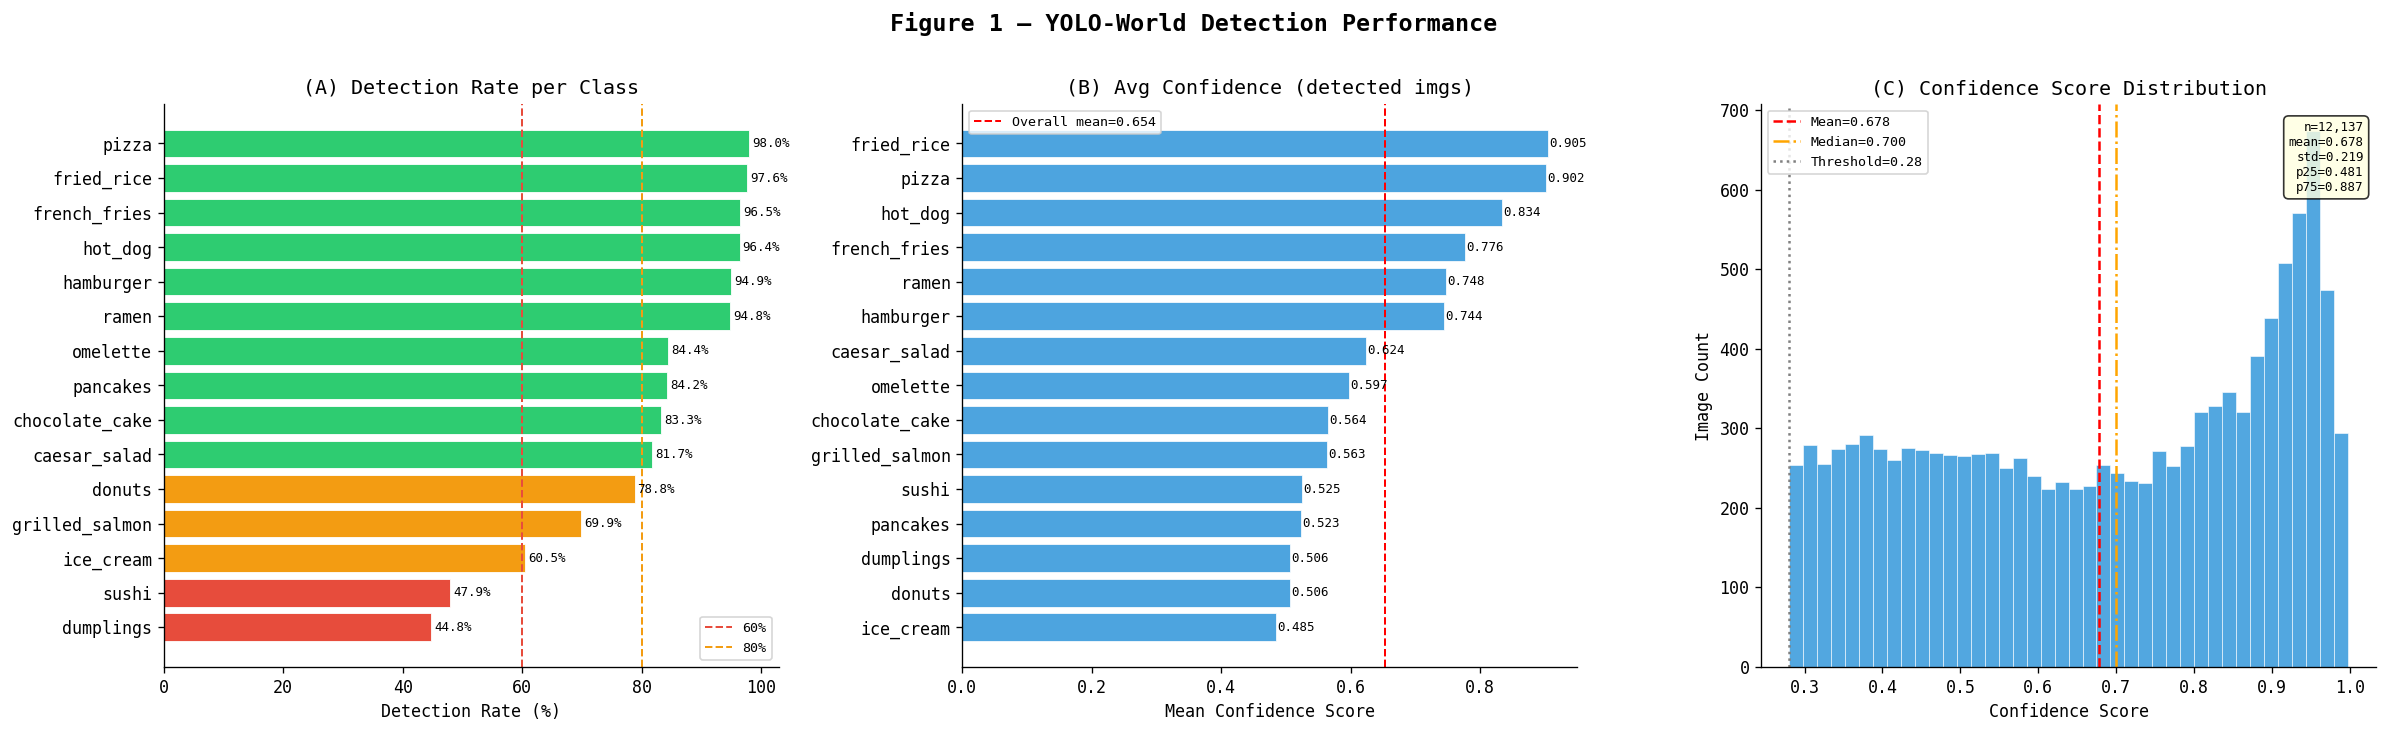

 Figure 1 saved


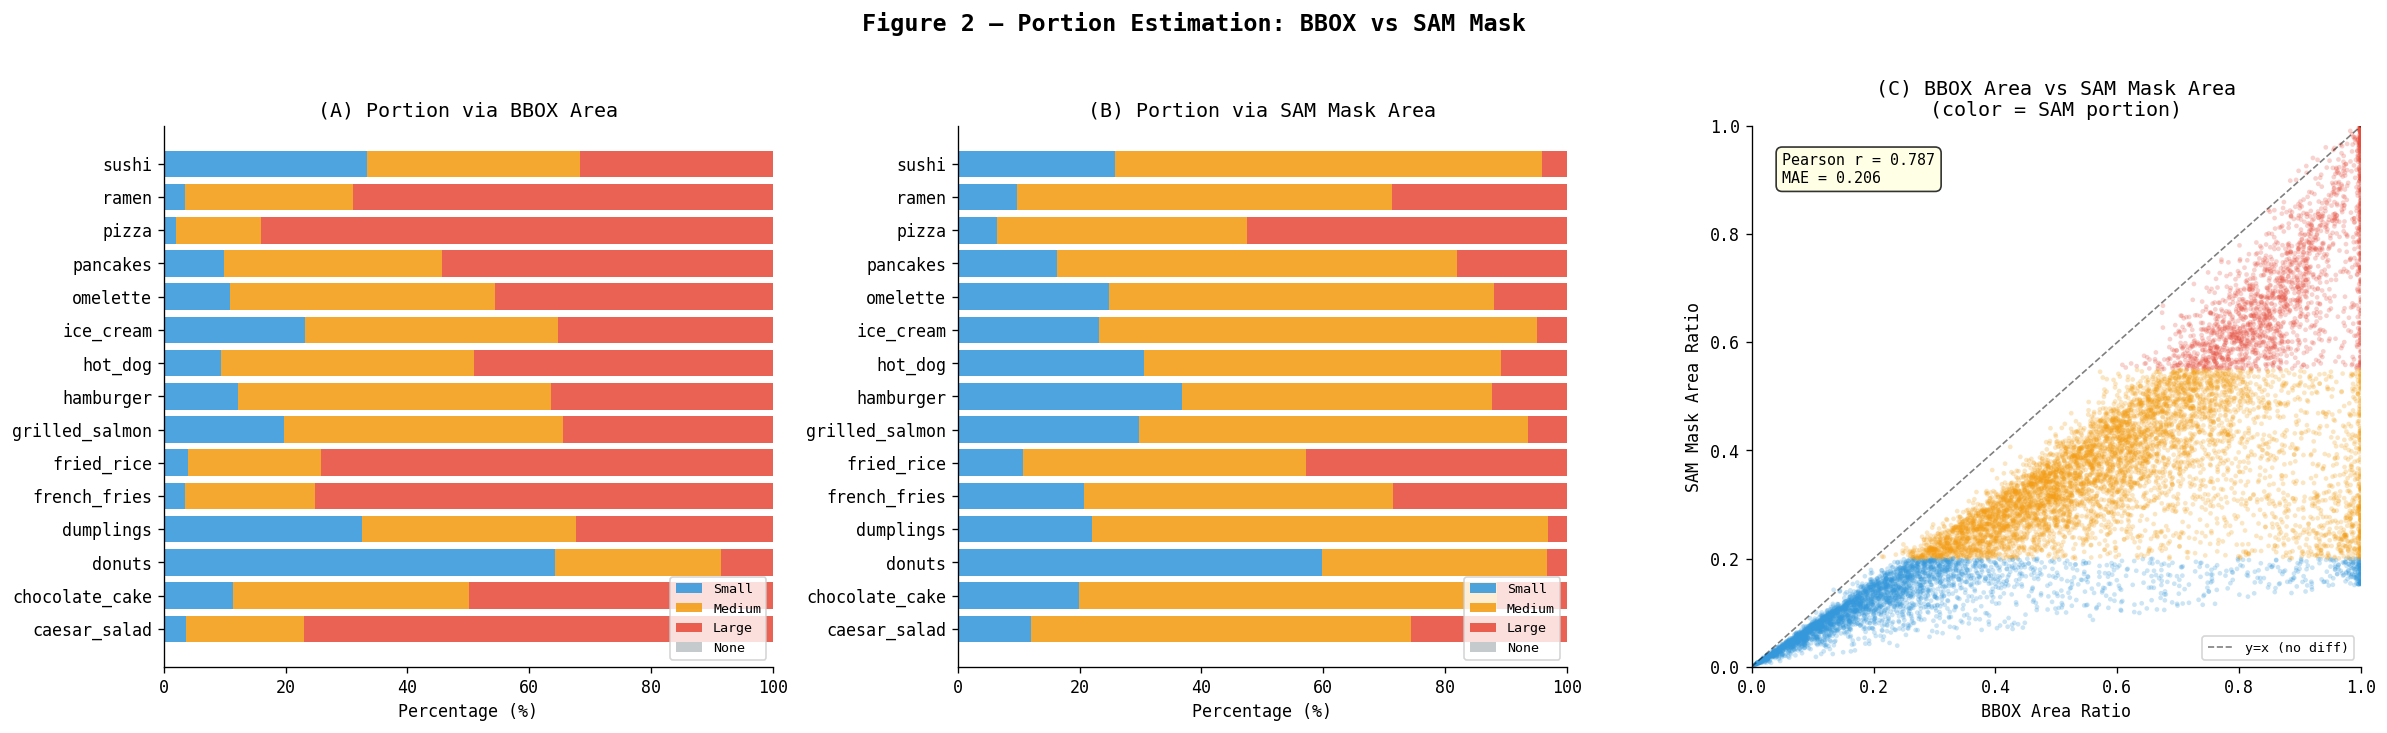

 Figure 2 saved


/tmp/ipykernel_57/4156032284.py:213: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(mask_data, labels=SELECTED_CLASSES, vert=False,


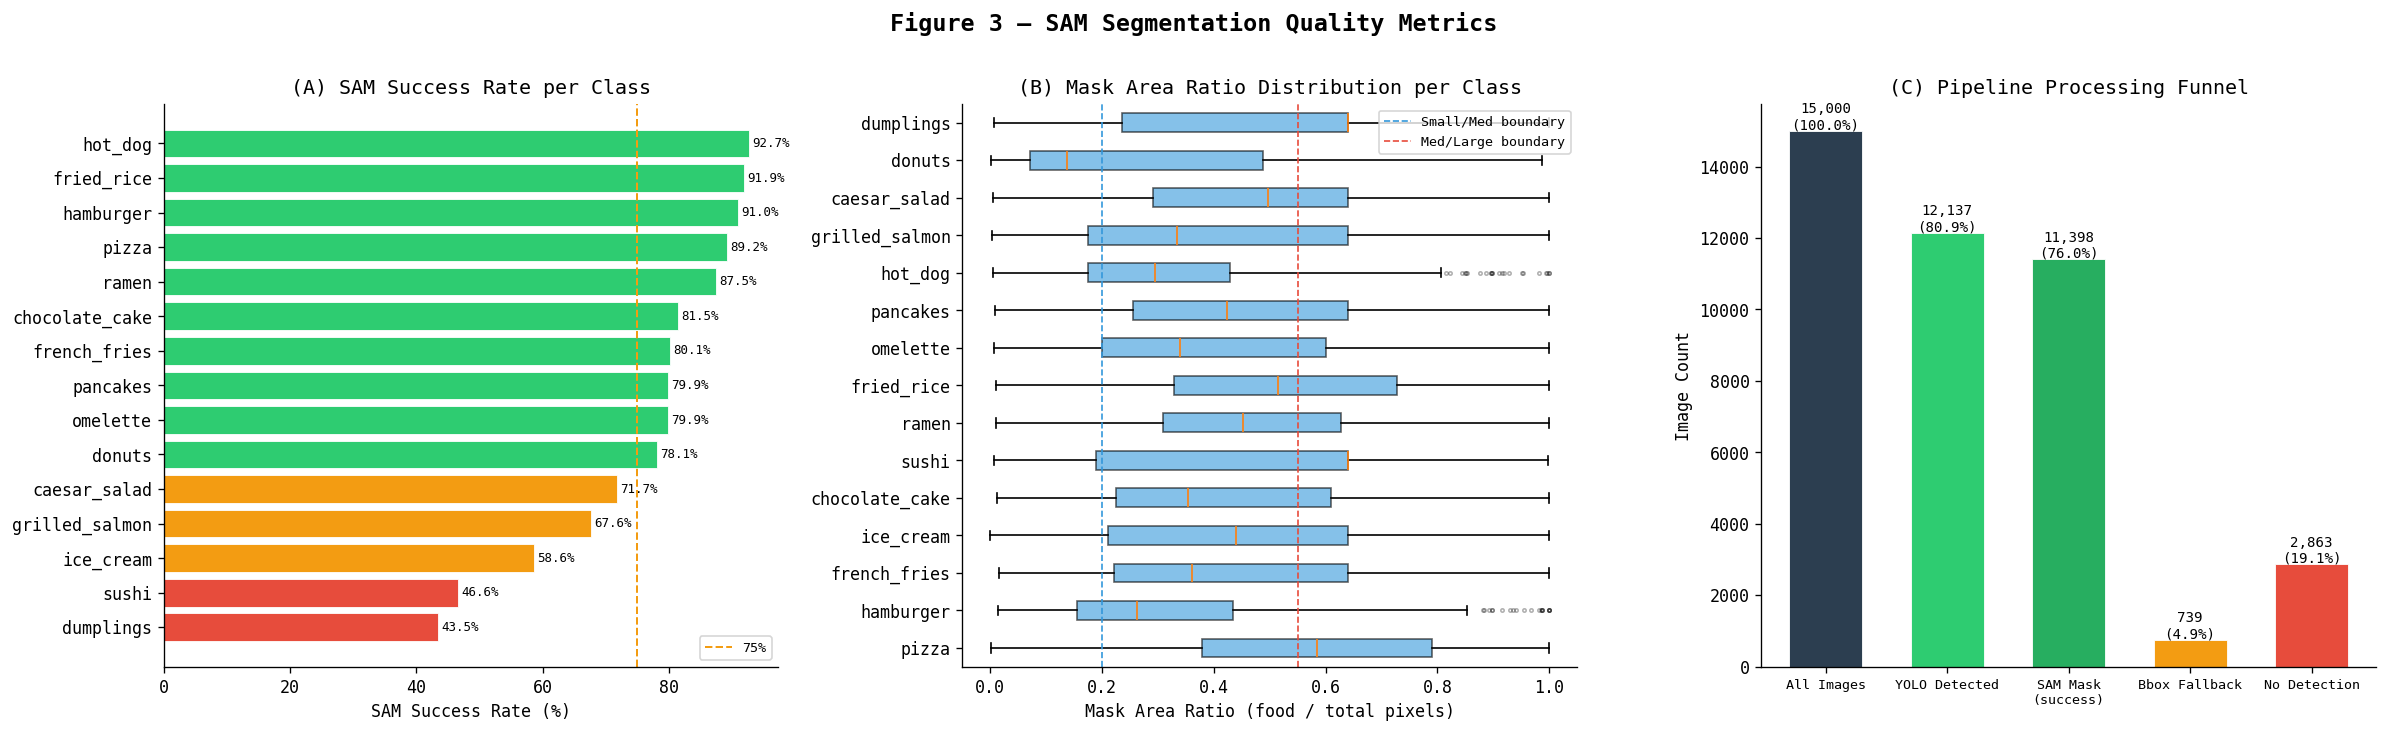

 Figure 3 saved


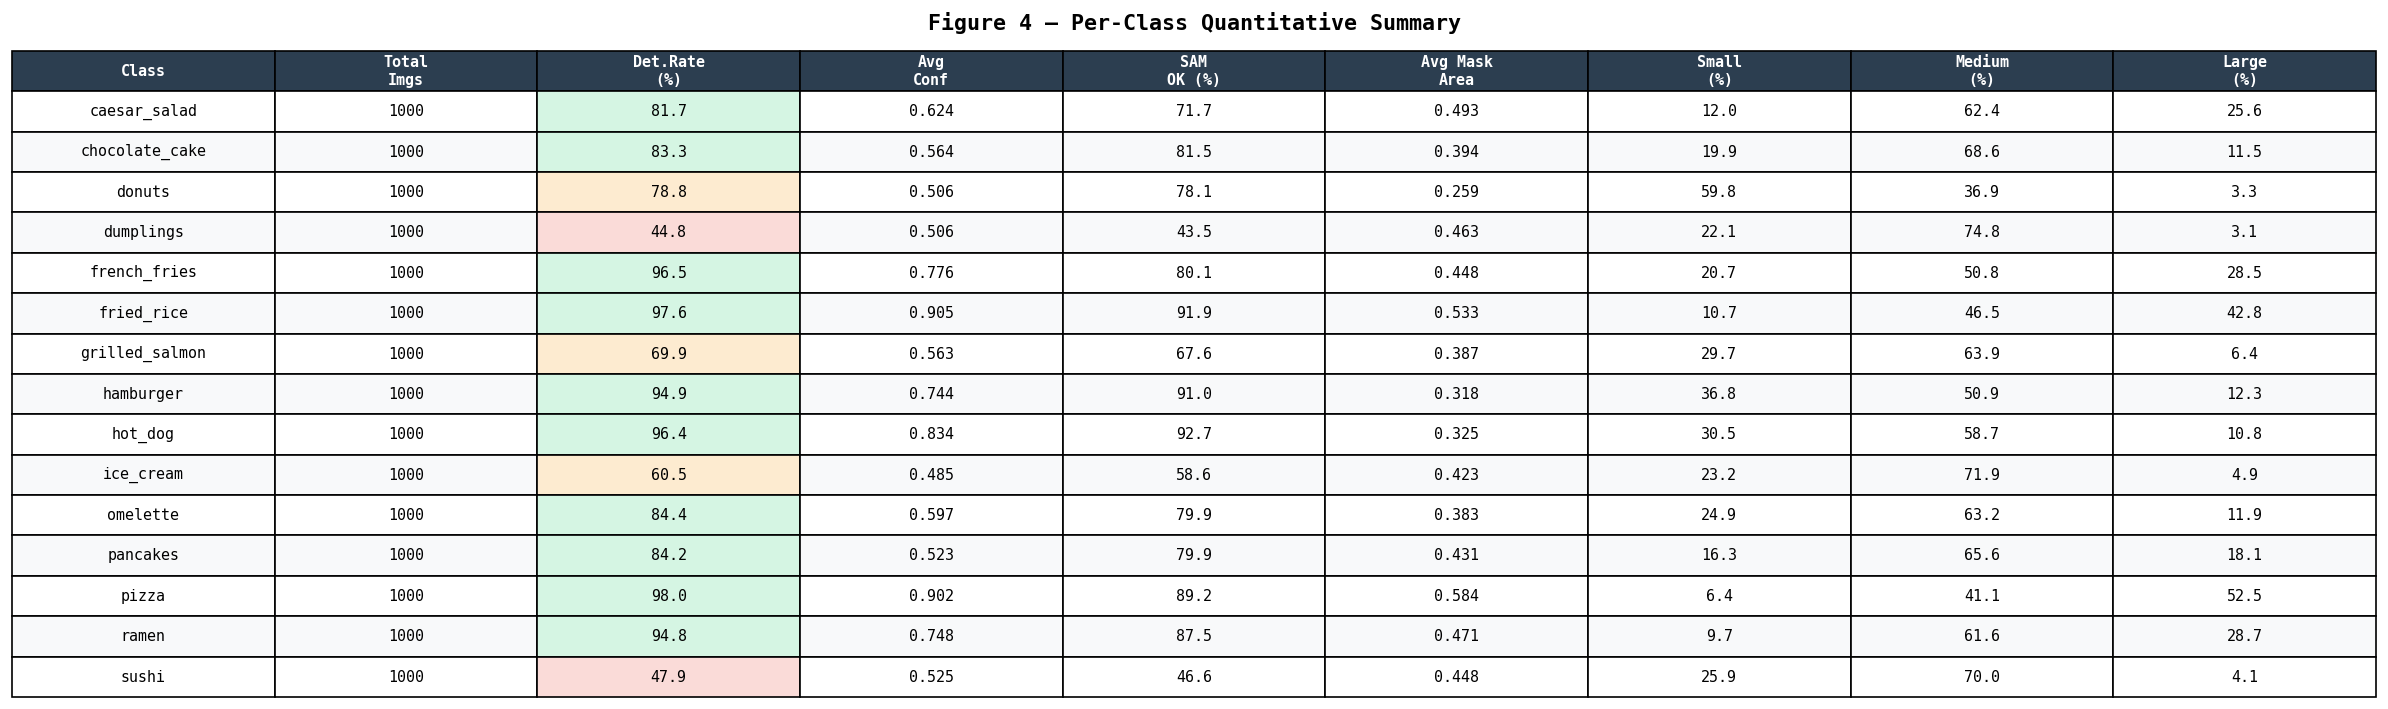

 Figure 4 saved

 All figures saved to: /kaggle/working/pipeline_b/viz
   fig1_detection_performance.png
   fig2_portion_estimation.png
   fig3_sam_quality.png
   fig4_summary_table.png


In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from pathlib import Path
CONF_THRESH = 0.28
matplotlib.rcParams.update({
    'font.family': 'monospace',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 120,
})

OUTPUT_ROOT = Path('/kaggle/working/pipeline_b')
STATS_DIR   = OUTPUT_ROOT / 'stats'
VIZ_DIR     = OUTPUT_ROOT / 'viz'
VIZ_DIR.mkdir(exist_ok=True)

SELECTED_CLASSES = [
    "pizza", "hamburger", "french_fries", "ice_cream", "chocolate_cake",
    "sushi", "ramen", "fried_rice", "omelette", "pancakes",
    "hot_dog", "grilled_salmon", "caesar_salad", "donuts", "dumplings"
]

df_yolo = pd.read_csv(STATS_DIR / 'yolo_detection_stats.csv')
df_sam  = pd.read_csv(STATS_DIR / 'sam_segmentation_stats.csv')

# Merge for combined analysis
df = pd.merge(df_yolo, df_sam, on=['class','stem'], how='left')
df['mask_area_ratio']  = df['mask_area_ratio'].fillna(df['bbox_area_ratio'])
df['used_sam']         = df['used_sam'].fillna(False)
df['portion_mask']     = df['portion_mask'].fillna(df['portion_bbox'])

print(f"Combined dataset: {len(df):,} images")
print(f"   Has detection:  {df['has_detection'].sum():,} ({df['has_detection'].mean()*100:.1f}%)")
print(f"   SAM succeeded:  {df['used_sam'].sum():,} ({df['used_sam'].mean()*100:.1f}%)")

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 1: YOLO-World Detection Performance (3 subplots)
# ─────────────────────────────────────────────────────────────────────────────
fig1, axes = plt.subplots(1, 3, figsize=(20, 6))
fig1.suptitle('Figure 1 — YOLO-World Detection Performance',
              fontsize=14, fontweight='bold', y=1.01)

# 1A. Detection rate per class
det_by_cls = (df.groupby('class')['has_detection']
                .mean()
                .sort_values()
                .rename('det_rate'))
colors_dr  = ['#e74c3c' if r < 0.60 else '#f39c12' if r < 0.80 else '#2ecc71'
               for r in det_by_cls.values]
bars = axes[0].barh(det_by_cls.index, det_by_cls.values * 100,
                    color=colors_dr, edgecolor='white', linewidth=0.5)
axes[0].axvline(60, color='#e74c3c', ls='--', lw=1.2, label='60%')
axes[0].axvline(80, color='#f39c12', ls='--', lw=1.2, label='80%')
axes[0].set_xlabel('Detection Rate (%)')
axes[0].set_title('(A) Detection Rate per Class')
axes[0].legend(fontsize=8)
for bar, val in zip(bars, det_by_cls.values):
    axes[0].text(val*100 + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val*100:.1f}%', va='center', fontsize=7.5)

# 1B. Avg confidence per class (only detected images)
det_only = df[df['has_detection']]
conf_cls  = (det_only.groupby('class')['max_conf']
                      .mean()
                      .sort_values())
axes[1].barh(conf_cls.index, conf_cls.values, color='#3498db',
             edgecolor='white', linewidth=0.5, alpha=0.88)
axes[1].axvline(conf_cls.mean(), color='red', ls='--', lw=1.2,
                label=f'Overall mean={conf_cls.mean():.3f}')
axes[1].set_xlabel('Mean Confidence Score')
axes[1].set_title('(B) Avg Confidence (detected imgs)')
axes[1].legend(fontsize=8)
for v, (cls_, val) in enumerate(conf_cls.items()):
    axes[1].text(val + 0.002, v, f'{val:.3f}', va='center', fontsize=7.5)

# 1C. Confidence score distribution
conf_vals = det_only['max_conf']
n, bins, patches = axes[2].hist(conf_vals, bins=40, color='#3498db',
                                edgecolor='white', linewidth=0.4, alpha=0.85)
axes[2].axvline(conf_vals.mean(),   color='red',    ls='--', lw=1.5,
                label=f'Mean={conf_vals.mean():.3f}')
axes[2].axvline(conf_vals.median(), color='orange', ls='-.',  lw=1.5,
                label=f'Median={conf_vals.median():.3f}')
axes[2].axvline(CONF_THRESH, color='gray', ls=':', lw=1.5,
                label=f'Threshold={CONF_THRESH}')
axes[2].set_xlabel('Confidence Score')
axes[2].set_ylabel('Image Count')
axes[2].set_title('(C) Confidence Score Distribution')
axes[2].legend(fontsize=8)

# Add stats text box
stats_txt = (f"n={len(conf_vals):,}\n"
             f"mean={conf_vals.mean():.3f}\n"
             f"std={conf_vals.std():.3f}\n"
             f"p25={conf_vals.quantile(.25):.3f}\n"
             f"p75={conf_vals.quantile(.75):.3f}")
axes[2].text(0.98, 0.97, stats_txt, transform=axes[2].transAxes,
             fontsize=7.5, va='top', ha='right',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
fig1.savefig(VIZ_DIR / 'fig1_detection_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figure 1 saved")

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 2: Portion Estimation — BBOX vs MASK comparison (3 subplots)
# ─────────────────────────────────────────────────────────────────────────────
PORTION_COLORS = {'Small': '#3498db', 'Medium': '#f39c12',
                  'Large': '#e74c3c', 'None': '#bdc3c7'}

fig2, axes = plt.subplots(1, 3, figsize=(20, 6))
fig2.suptitle('Figure 2 — Portion Estimation: BBOX vs SAM Mask',
              fontsize=14, fontweight='bold', y=1.01)

# 2A. Portion distribution — BBOX (stacked bar per class)
portion_order = ['Small', 'Medium', 'Large', 'None']
pivot_bbox = (df.groupby(['class', 'portion_bbox'])
                .size()
                .unstack(fill_value=0)
                .reindex(columns=portion_order, fill_value=0))
pivot_bbox_pct = pivot_bbox.div(pivot_bbox.sum(axis=1), axis=0) * 100

bottom = np.zeros(len(pivot_bbox_pct))
for portion in portion_order:
    if portion in pivot_bbox_pct.columns:
        vals = pivot_bbox_pct[portion].values
        axes[0].barh(pivot_bbox_pct.index, vals, left=bottom,
                     color=PORTION_COLORS[portion], label=portion, alpha=0.88)
        bottom += vals
axes[0].set_xlabel('Percentage (%)')
axes[0].set_title('(A) Portion via BBOX Area')
axes[0].legend(fontsize=8, loc='lower right')
axes[0].set_xlim(0, 100)

# 2B. Portion distribution — SAM mask (stacked bar per class)
pivot_sam = (df.groupby(['class', 'portion_mask'])
               .size()
               .unstack(fill_value=0)
               .reindex(columns=portion_order, fill_value=0))
pivot_sam_pct = pivot_sam.div(pivot_sam.sum(axis=1), axis=0) * 100

bottom = np.zeros(len(pivot_sam_pct))
for portion in portion_order:
    if portion in pivot_sam_pct.columns:
        vals = pivot_sam_pct[portion].values
        axes[1].barh(pivot_sam_pct.index, vals, left=bottom,
                     color=PORTION_COLORS[portion], label=portion, alpha=0.88)
        bottom += vals
axes[1].set_xlabel('Percentage (%)')
axes[1].set_title('(B) Portion via SAM Mask Area')
axes[1].legend(fontsize=8, loc='lower right')
axes[1].set_xlim(0, 100)

# 2C. Scatter: bbox_area vs mask_area (shows how much they differ)
sam_only = df[df['used_sam']]
scatter = axes[2].scatter(
    sam_only['bbox_area_ratio'], sam_only['mask_area_ratio'],
    c=[{'Small':'#3498db','Medium':'#f39c12','Large':'#e74c3c','None':'#bdc3c7'}
       .get(p,'#bdc3c7') for p in sam_only['portion_mask']],
    alpha=0.25, s=8, linewidths=0
)
axes[2].plot([0,1],[0,1], 'k--', lw=1, alpha=0.5, label='y=x (no diff)')
axes[2].set_xlabel('BBOX Area Ratio')
axes[2].set_ylabel('SAM Mask Area Ratio')
axes[2].set_title('(C) BBOX Area vs SAM Mask Area\n(color = SAM portion)')
axes[2].set_xlim(0, 1); axes[2].set_ylim(0, 1)
axes[2].legend(fontsize=8)

# Pearson correlation
corr = sam_only[['bbox_area_ratio','mask_area_ratio']].corr().iloc[0,1]
mae  = (sam_only['bbox_area_ratio'] - sam_only['mask_area_ratio']).abs().mean()
axes[2].text(0.05, 0.95,
             f"Pearson r = {corr:.3f}\nMAE = {mae:.3f}",
             transform=axes[2].transAxes, fontsize=9, va='top',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
fig2.savefig(VIZ_DIR / 'fig2_portion_estimation.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figure 2 saved")

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 3: SAM Quality Metrics (3 subplots)
# ─────────────────────────────────────────────────────────────────────────────
fig3, axes = plt.subplots(1, 3, figsize=(20, 6))
fig3.suptitle('Figure 3 — SAM Segmentation Quality Metrics',
              fontsize=14, fontweight='bold', y=1.01)

# 3A. SAM success rate per class
sam_rate_cls = (df.groupby('class')['used_sam']
                  .mean()
                  .sort_values())
colors_sam = ['#e74c3c' if r < 0.5 else '#f39c12' if r < 0.75 else '#2ecc71'
              for r in sam_rate_cls.values]
bars = axes[0].barh(sam_rate_cls.index, sam_rate_cls.values * 100,
                    color=colors_sam, edgecolor='white', linewidth=0.5)
axes[0].axvline(75, color='#f39c12', ls='--', lw=1.2, label='75%')
axes[0].set_xlabel('SAM Success Rate (%)')
axes[0].set_title('(A) SAM Success Rate per Class')
axes[0].legend(fontsize=8)
for bar, val in zip(bars, sam_rate_cls.values):
    axes[0].text(val*100 + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val*100:.1f}%', va='center', fontsize=7.5)

# 3B. Mask area ratio boxplot per class
mask_data = [df[df['class'] == cls]['mask_area_ratio'].dropna().values
             for cls in SELECTED_CLASSES]
bp = axes[1].boxplot(mask_data, labels=SELECTED_CLASSES, vert=False,
                     patch_artist=True, flierprops=dict(markersize=2, alpha=0.3))
for patch in bp['boxes']:
    patch.set_facecolor('#3498db')
    patch.set_alpha(0.6)
axes[1].axvline(0.20, color='#3498db', ls='--', lw=1, label='Small/Med boundary')
axes[1].axvline(0.55, color='#e74c3c', ls='--', lw=1, label='Med/Large boundary')
axes[1].set_xlabel('Mask Area Ratio (food / total pixels)')
axes[1].set_title('(B) Mask Area Ratio Distribution per Class')
axes[1].legend(fontsize=8)

# 3C. Overall pipeline funnel (sankey-like bar)
n_total     = len(df)
n_detected  = int(df['has_detection'].sum())
n_sam_ok    = int(df['used_sam'].sum())
n_fallback  = n_detected - n_sam_ok
n_no_det    = n_total - n_detected

stages      = ['All Images', 'YOLO Detected', 'SAM Mask\n(success)', 'Bbox Fallback', 'No Detection']
values      = [n_total, n_detected, n_sam_ok, n_fallback, n_no_det]
bar_colors  = ['#2c3e50', '#2ecc71', '#27ae60', '#f39c12', '#e74c3c']

bars = axes[2].bar(stages, values, color=bar_colors, edgecolor='white',
                   linewidth=0.5, width=0.6)
for bar, val in zip(bars, values):
    pct = val / n_total * 100
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=8.5)
axes[2].set_ylabel('Image Count')
axes[2].set_title('(C) Pipeline Processing Funnel')
axes[2].tick_params(axis='x', labelsize=8)

plt.tight_layout()
fig3.savefig(VIZ_DIR / 'fig3_sam_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figure 3 saved")

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 4: Summary Table (printable for report)
# ─────────────────────────────────────────────────────────────────────────────
summary_tbl = df.groupby('class').agg(
    n_total         =('stem',            'count'),
    det_rate_pct    =('has_detection',   lambda x: round(x.mean()*100, 1)),
    avg_conf        =('max_conf',        lambda x: round(x[x>0].mean(), 3) if (x>0).any() else 0),
    sam_rate_pct    =('used_sam',        lambda x: round(x.mean()*100, 1)),
    avg_mask_area   =('mask_area_ratio', lambda x: round(x[x>0].mean(), 3) if (x>0).any() else 0),
    portion_small_pct=('portion_mask',   lambda x: round((x=='Small').mean()*100, 1)),
    portion_med_pct  =('portion_mask',   lambda x: round((x=='Medium').mean()*100, 1)),
    portion_large_pct=('portion_mask',   lambda x: round((x=='Large').mean()*100, 1)),
).reset_index()

fig4, ax = plt.subplots(figsize=(20, 6))
ax.axis('off')
col_labels = [
    'Class', 'Total\nImgs', 'Det.Rate\n(%)', 'Avg\nConf',
    'SAM\nOK (%)', 'Avg Mask\nArea', 'Small\n(%)', 'Medium\n(%)', 'Large\n(%)'
]
tbl_data = summary_tbl.values.tolist()
table = ax.table(
    cellText   = tbl_data,
    colLabels  = col_labels,
    cellLoc    = 'center',
    loc        = 'center',
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.8)

# Color header
for j in range(len(col_labels)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Alternate row colors
for i in range(1, len(tbl_data) + 1):
    bg = '#f8f9fa' if i % 2 == 0 else 'white'
    for j in range(len(col_labels)):
        table[i, j].set_facecolor(bg)
        # Color det_rate cell by value
        if j == 2:
            val = float(tbl_data[i-1][j])
            if val >= 80:
                table[i, j].set_facecolor('#d5f5e3')
            elif val >= 60:
                table[i, j].set_facecolor('#fdebd0')
            else:
                table[i, j].set_facecolor('#fadbd8')

ax.set_title('Figure 4 — Per-Class Quantitative Summary',
             fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
fig4.savefig(VIZ_DIR / 'fig4_summary_table.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figure 4 saved")

print(f"\n All figures saved to: {VIZ_DIR}")
print(f"   fig1_detection_performance.png")
print(f"   fig2_portion_estimation.png")
print(f"   fig3_sam_quality.png")
print(f"   fig4_summary_table.png")

# CELL 5 — SAMPLE GRID VISUALIZATION
## Hiển thị ảnh cụ thể để đánh giá chất lượng visual: Original | BBox | SAM
## 5 classes × 3 samples, mỗi sample = [Original | BBox Overlay | SAM Crop]

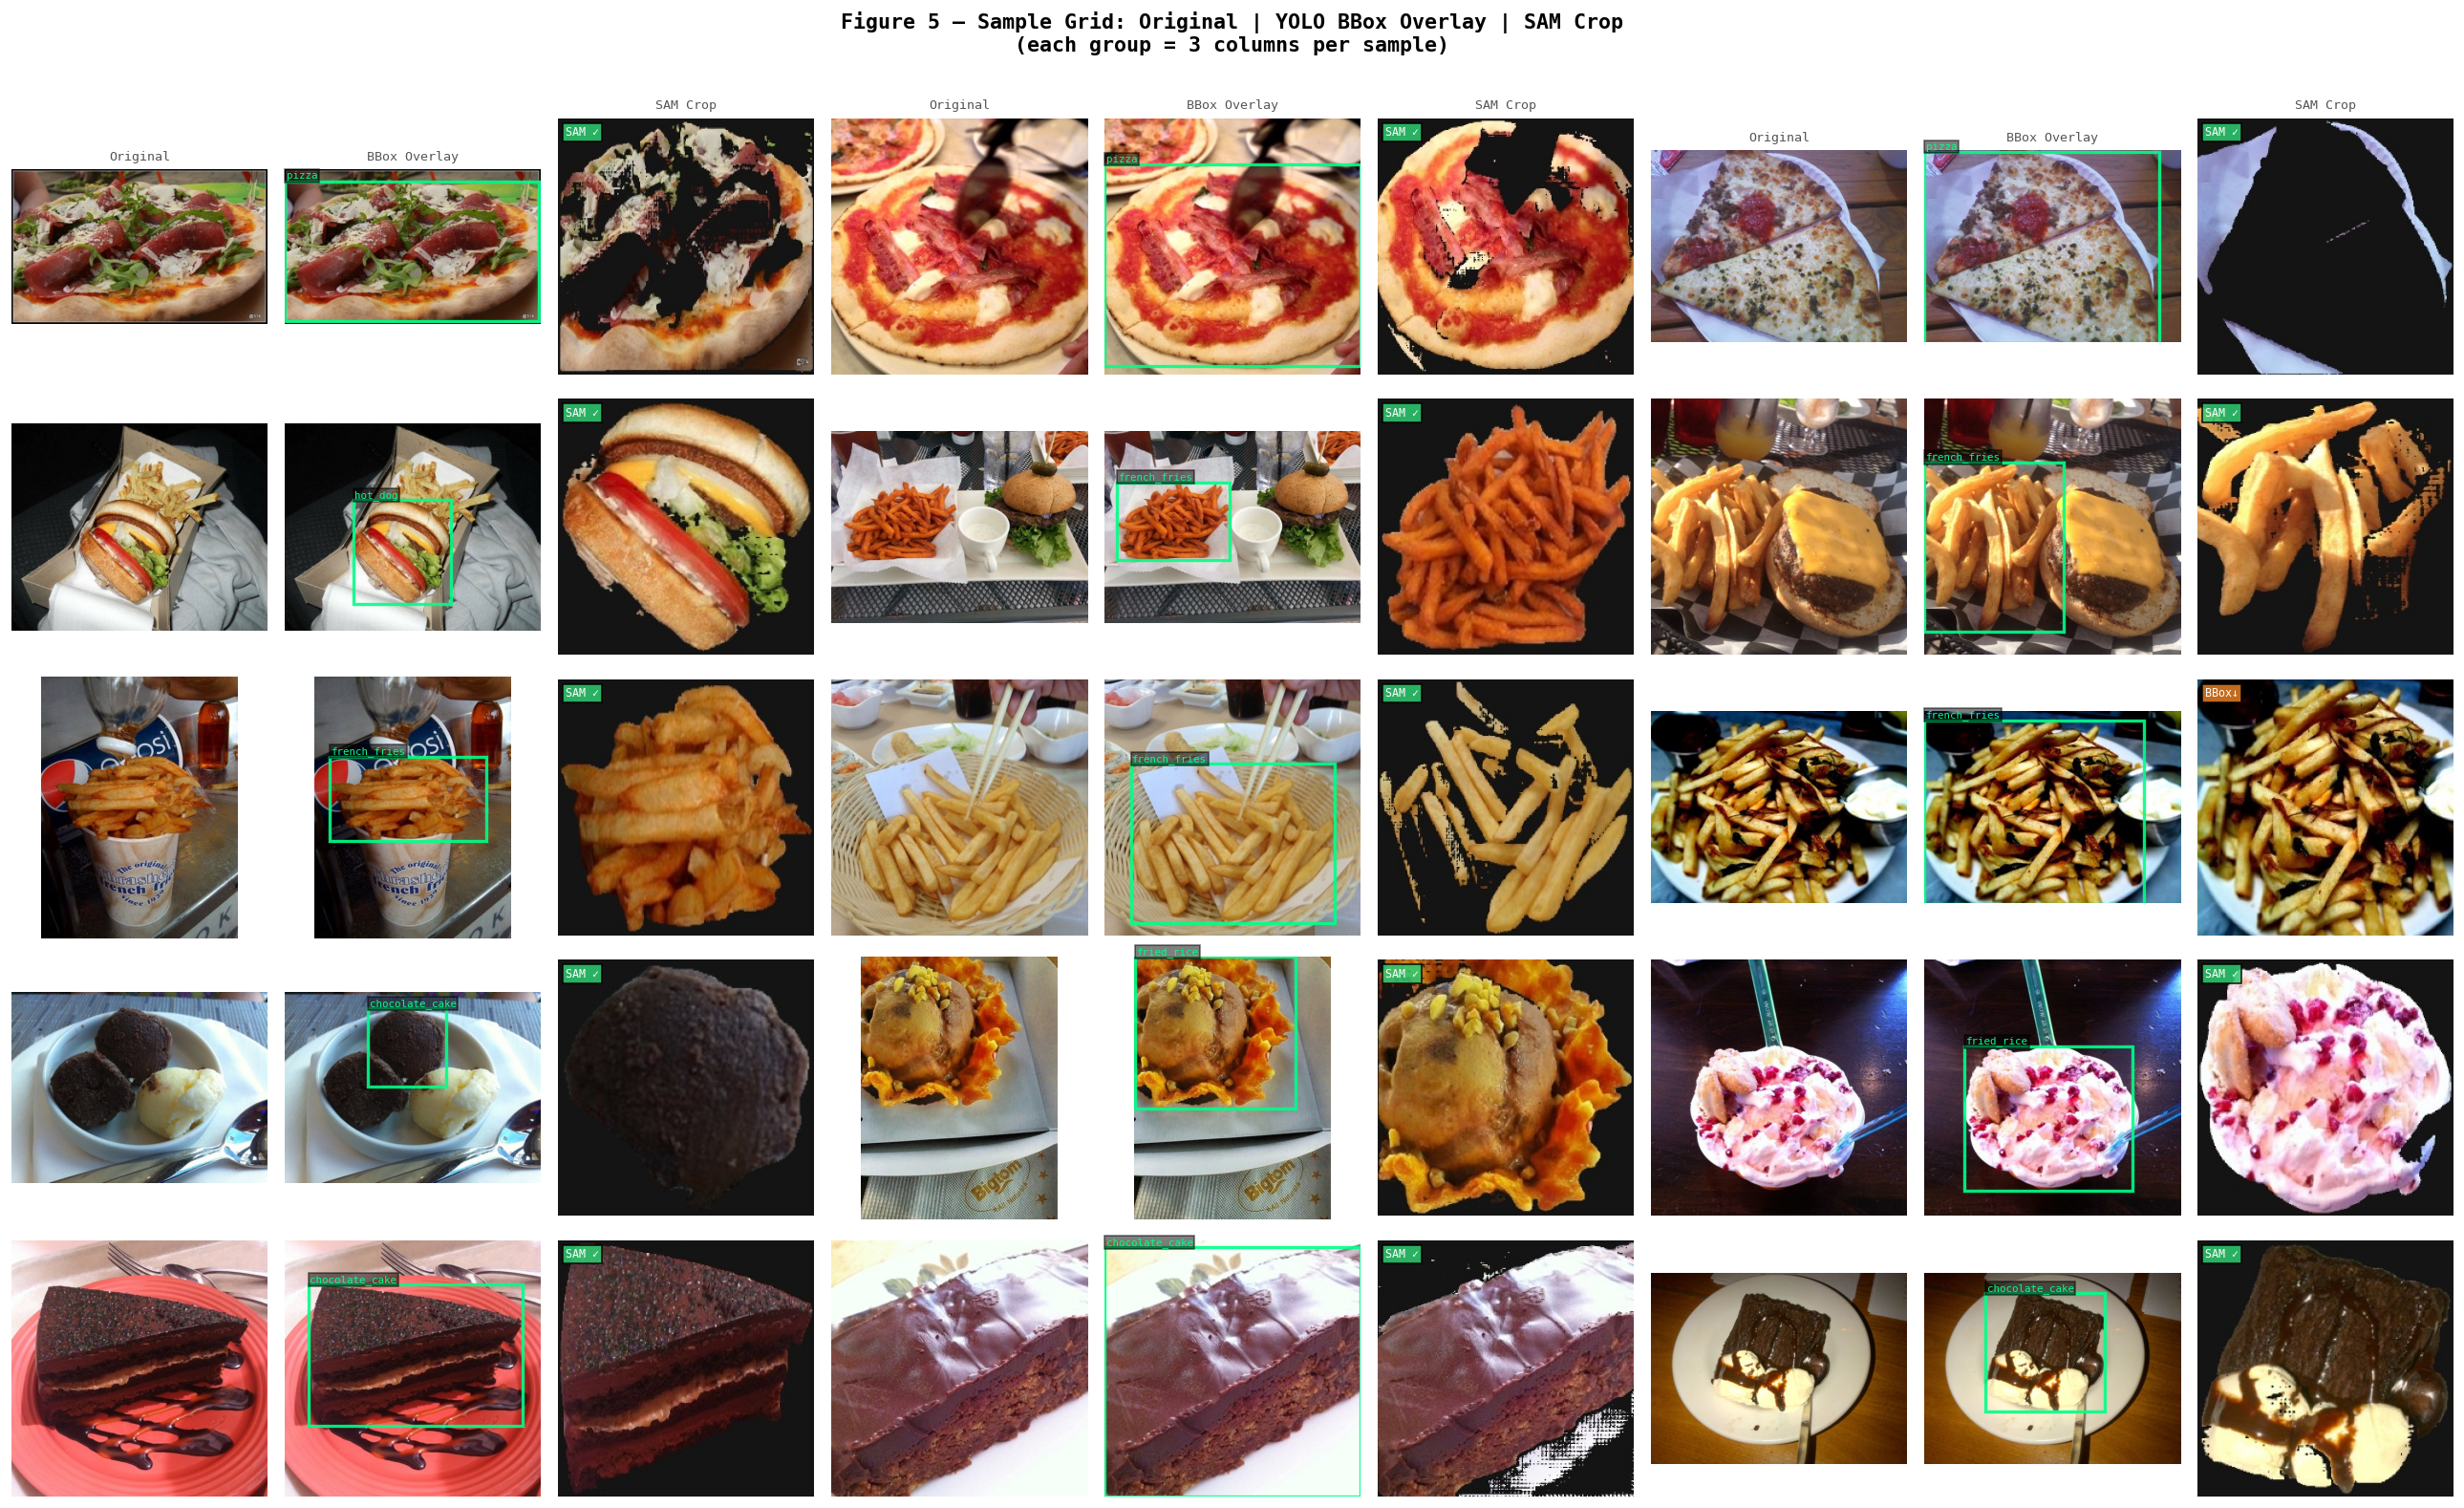

Figure 5 saved — Sample Grid
   Crops ready for CNN at: /kaggle/working/pipeline_b/crops
   All figures at: /kaggle/working/pipeline_b/viz


In [ ]:
import cv2
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
from pathlib import Path

DATASET_ROOT = Path('/kaggle/input/datasets/qunh999/101-15-classes')
OUTPUT_ROOT  = Path('/kaggle/working/pipeline_b')
LBL_DIR      = OUTPUT_ROOT / 'labels'
CROP_DIR     = OUTPUT_ROOT / 'crops'
MASK_DIR     = OUTPUT_ROOT / 'masked'
VIZ_DIR      = OUTPUT_ROOT / 'viz'

SELECTED_CLASSES = [
    "pizza", "hamburger", "french_fries", "ice_cream", "chocolate_cake",
    "sushi", "ramen", "fried_rice", "omelette", "pancakes",
    "hot_dog", "grilled_salmon", "caesar_salad", "donuts", "dumplings"
]
SAMPLES_PER_CLASS = 3   # số ảnh mẫu mỗi class
SHOW_CLASSES      = 5   # chỉ show 5 class đầu để grid vừa màn hình

df_yolo = pd.read_csv(OUTPUT_ROOT / 'stats' / 'yolo_detection_stats.csv')
df_sam  = pd.read_csv(OUTPUT_ROOT / 'stats' / 'sam_segmentation_stats.csv')
df      = pd.merge(df_yolo, df_sam, on=['class','stem'], how='left')
df['used_sam'] = df['used_sam'].fillna(False)

random.seed(42)
SHOW_CLS = SELECTED_CLASSES[:SHOW_CLASSES]
n_cols   = SAMPLES_PER_CLASS * 3  # [orig | bbox | crop] × N_samples
n_rows   = SHOW_CLASSES

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 2.4, n_rows * 2.6))
fig.suptitle('Figure 5 — Sample Grid: Original | YOLO BBox Overlay | SAM Crop\n'
             f'(each group = 3 columns per sample)',
             fontsize=13, fontweight='bold', y=1.01)

for row_idx, cls_name in enumerate(SHOW_CLS):
    cls_df = df[(df['class'] == cls_name) & (df['has_detection'] == True)]
    picks  = cls_df.sample(min(SAMPLES_PER_CLASS, len(cls_df)),
                           random_state=42)['stem'].tolist()

    for s_idx, stem in enumerate(picks[:SAMPLES_PER_CLASS]):
        col_orig  = s_idx * 3
        col_bbox  = s_idx * 3 + 1
        col_crop  = s_idx * 3 + 2

        ax_orig = axes[row_idx, col_orig]
        ax_bbox = axes[row_idx, col_bbox]
        ax_crop = axes[row_idx, col_crop]
        img_path = DATASET_ROOT / cls_name / f"{stem}.jpg"
        if not img_path.exists():
            img_path = DATASET_ROOT / cls_name / f"{stem}.png"

        img_bgr = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) if img_bgr is not None \
                  else np.zeros((224,224,3), dtype=np.uint8)
        H, W = img_rgb.shape[:2]

        ax_orig.imshow(img_rgb)
        ax_orig.axis('off')
        if s_idx == 0:
            ax_orig.set_ylabel(cls_name.replace('_',' ').title(),
                               fontsize=9, fontweight='bold', rotation=90,
                               labelpad=4)
        if row_idx == 0:
            ax_orig.set_title('Original', fontsize=8, color='#555')
        lbl_path = LBL_DIR / cls_name / f"{stem}.txt"
        ax_bbox.imshow(img_rgb)
        ax_bbox.axis('off')
        if row_idx == 0:
            ax_bbox.set_title('BBox Overlay', fontsize=8, color='#555')

        if lbl_path.exists():
            with open(lbl_path) as f:
                for line in f:
                    parts = line.split('#')[0].strip().split()
                    if len(parts) >= 5:
                        xc, yc, bw, bh = map(float, parts[1:5])
                        x1 = (xc - bw/2) * W
                        y1 = (yc - bh/2) * H
                        rect = patches.Rectangle(
                            (x1, y1), bw*W, bh*H,
                            linewidth=2, edgecolor='#00ff88',
                            facecolor='none', alpha=0.9
                        )
                        ax_bbox.add_patch(rect)
                        # Class label
                        cid = int(parts[0])
                        cls_short = SELECTED_CLASSES[cid] if cid < len(SELECTED_CLASSES) else str(cid)
                        ax_bbox.text(x1 + 3, y1 - 5, cls_short,
                                     fontsize=6.5, color='#00ff88',
                                     bbox=dict(facecolor='black', alpha=0.5, pad=1))
                        break
        crop_path = CROP_DIR / cls_name / f"{stem}.jpg"
        ax_crop.axis('off')
        if row_idx == 0:
            ax_crop.set_title('SAM Crop', fontsize=8, color='#555')

        if crop_path.exists():
            crop_bgr = cv2.imread(str(crop_path))
            crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
            ax_crop.imshow(crop_rgb)
            sam_row = df[(df['class']==cls_name) & (df['stem']==stem)]
            used    = bool(sam_row['used_sam'].values[0]) if len(sam_row) > 0 else False
            badge   = 'SAM ✓' if used else 'BBox↓'
            color   = '#2ecc71'  if used else '#e67e22'
            ax_crop.text(0.03, 0.97, badge, transform=ax_crop.transAxes,
                         fontsize=7, va='top', color='white',
                         bbox=dict(facecolor=color, alpha=0.85, pad=2))
        else:
            ax_crop.imshow(np.ones((224,224,3), dtype=np.uint8)*220)
            ax_crop.text(0.5, 0.5, 'No crop\nsaved',
                         transform=ax_crop.transAxes,
                         ha='center', va='center', fontsize=8, color='gray')


plt.tight_layout()
fig.savefig(VIZ_DIR / 'fig5_sample_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 5 saved — Sample Grid")
print(f"   Crops ready for CNN at: {CROP_DIR}")
print(f"   All figures at: {VIZ_DIR}")


In [ ]:
# ============================================================
# CELL BỔ SUNG — Tính IoU từ mask đã lưu (không cần chạy SAM lại)
# ============================================================
import cv2
import numpy as np
import pandas as pd
from pathlib import Path

OUTPUT_ROOT = Path('/kaggle/working/pipeline_b')
LBL_DIR     = OUTPUT_ROOT / 'labels'
MASK_DIR    = OUTPUT_ROOT / 'masked'
STATS_DIR   = OUTPUT_ROOT / 'stats'

SELECTED_CLASSES = [
    "pizza", "hamburger", "french_fries", "ice_cream", "chocolate_cake",
    "sushi", "ramen", "fried_rice", "omelette", "pancakes",
    "hot_dog", "grilled_salmon", "caesar_salad", "donuts", "dumplings"
]

df_sam = pd.read_csv(STATS_DIR / 'sam_segmentation_stats.csv')
sam_ok = df_sam[df_sam['used_sam'] == True].copy()
print(f"Tính IoU cho {len(sam_ok):,} ảnh SAM thành công...")

iou_rows = []
fail = 0

for _, row in sam_ok.iterrows():
    cls_name = row['class']
    stem     = row['stem']

    mask_path = MASK_DIR / cls_name / f"{stem}.jpg"
    lbl_path  = LBL_DIR  / cls_name / f"{stem}.txt"

    if not mask_path.exists() or not lbl_path.exists():
        fail += 1
        continue
    mask_img = cv2.imread(str(mask_path))   # 224×224, BGR
    if mask_img is None:
        fail += 1
        continue

    H, W = mask_img.shape[:2]  # 224, 224

    BG = np.array([20, 20, 20])
    dist = np.sqrt(np.sum((mask_img.astype(float) - BG)**2, axis=2))
    food_mask = dist > 15  # ngưỡng khoảng cách ~8.7 → an toàn hơn

    # ── Đọc bbox → tạo bbox mask ở cùng 224×224 ─────────────────────────────
    try:
        first_line = lbl_path.read_text().splitlines()[0].split('#')[0].strip()
        parts = first_line.split()
        xc, yc, bw, bh = map(float, parts[1:5])
        x1 = int((xc - bw/2) * W)
        y1 = int((yc - bh/2) * H)
        x2 = int((xc + bw/2) * W)
        y2 = int((yc + bh/2) * H)
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(W, x2), min(H, y2)
    except Exception:
        fail += 1
        continue

    bbox_mask = np.zeros((H, W), dtype=bool)
    bbox_mask[y1:y2, x1:x2] = True

    # ── Tính IoU ─────────────────────────────────────────────────────────────
    inter = (food_mask & bbox_mask).sum()
    union = (food_mask | bbox_mask).sum()
    iou   = round(float(inter) / (float(union) + 1e-6), 4)

    iou_rows.append({'class': cls_name, 'stem': stem, 'sam_bbox_overlap': iou})

df_iou = pd.DataFrame(iou_rows)
print(f" Tính được {len(df_iou):,} IoU | fail={fail}")

# ── Merge vào sam_stats ───────────────────────────────────────────────────────
df_sam = df_sam.merge(df_iou, on=['class','stem'], how='left')
df_sam['sam_bbox_overlap'] = df_sam['sam_bbox_overlap'].fillna(0.0)
df_sam.to_csv(STATS_DIR / 'sam_segmentation_stats.csv', index=False)
print(f" Đã cập nhật sam_segmentation_stats.csv")

# ── Summary ───────────────────────────────────────────────────────────────────
iou_vals = df_sam[df_sam['used_sam'] == True]['sam_bbox_overlap']
print(f"\nIoU (SAM mask vs YOLO bbox) — {len(iou_vals):,} ảnh:")
print(f"   Mean   : {iou_vals.mean():.3f}")
print(f"   Median : {iou_vals.median():.3f}")
print(f"   Std    : {iou_vals.std():.3f}")
print(f"   > 0.5  : {(iou_vals > 0.5).mean()*100:.1f}%")
print(f"   > 0.7  : {(iou_vals > 0.7).mean()*100:.1f}%")

print(f"\n IoU trung bình theo class:")
print(df_sam[df_sam['used_sam']==True]
      .groupby('class')['sam_bbox_overlap']
      .mean().round(3).sort_values().to_string())

Tính IoU cho 11,398 ảnh SAM thành công...
 Tính được 11,398 IoU | fail=0
 Đã cập nhật sam_segmentation_stats.csv

IoU (SAM mask vs YOLO bbox) — 11,398 ảnh:
   Mean   : 0.502
   Median : 0.527
   Std    : 0.242
   > 0.5  : 53.6%
   > 0.7  : 24.5%

 IoU trung bình theo class:
class
donuts            0.242
sushi             0.369
dumplings         0.379
grilled_salmon    0.438
ice_cream         0.443
hot_dog           0.467
hamburger         0.468
chocolate_cake    0.485
omelette          0.493
french_fries      0.509
pancakes          0.538
caesar_salad      0.563
ramen             0.605
fried_rice        0.671
pizza             0.676


In [ ]:
# Tạo thư mục bbox_viz từ labels đã có
import cv2
import numpy as np
from pathlib import Path

DATASET_ROOT = Path('/kaggle/input/datasets/qunh999/101-15-classes')
OUTPUT_ROOT  = Path('/kaggle/working/pipeline_b')
LBL_DIR      = OUTPUT_ROOT / 'labels'
BBOX_VIZ_DIR = OUTPUT_ROOT / 'bbox_viz'

SELECTED_CLASSES = [
    "pizza", "hamburger", "french_fries", "ice_cream", "chocolate_cake",
    "sushi", "ramen", "fried_rice", "omelette", "pancakes",
    "hot_dog", "grilled_salmon", "caesar_salad", "donuts", "dumplings"
]

SAMPLES_PER_CLASS = 20

for cls_name in SELECTED_CLASSES:
    out_dir = BBOX_VIZ_DIR / cls_name
    out_dir.mkdir(parents=True, exist_ok=True)

    lbl_files = [f for f in (LBL_DIR/cls_name).glob('*.txt')
                 if f.stat().st_size > 0][:SAMPLES_PER_CLASS]

    for lbl_path in lbl_files:
        stem     = lbl_path.stem
        img_path = DATASET_ROOT / cls_name / f"{stem}.jpg"
        if not img_path.exists():
            continue

        img = cv2.imread(str(img_path))
        if img is None:
            continue
        H, W = img.shape[:2]

        # Đọc tất cả bbox trong file
        for line in lbl_path.read_text().splitlines():
            parts = line.split('#')[0].strip().split()
            if len(parts) < 5:
                continue
            cid = int(parts[0])
            xc, yc, bw, bh = map(float, parts[1:5])
            x1 = int((xc - bw/2) * W); y1 = int((yc - bh/2) * H)
            x2 = int((xc + bw/2) * W); y2 = int((yc + bh/2) * H)

            cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,136), 2)
            label = f"{SELECTED_CLASSES[cid]} {float(line.split('conf=')[-1].strip()) if 'conf=' in line else ''}"
            cv2.putText(img, label, (x1, y1-8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0,255,136), 2)

        cv2.imwrite(str(out_dir / f"{stem}.jpg"), img)

print(" bbox_viz/ đã tạo xong")

 bbox_viz/ đã tạo xong


In [ ]:
import shutil
shutil.make_archive('/kaggle/working/pipeline_b_1', 'zip', '/kaggle/working/pipeline_b')

'/kaggle/working/pipeline_b_1.zip'